In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

In [2]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left", "predicted_drive_points_ev"]

/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML


In [3]:
# Reset the modules
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

import process_data

training_data = process_data.load_data(interpolated_dir, 
                                       years = [2016, 2017,2018, 2019, 2020, 2021, 2022, 2023], 
                                       history_length = 4, 
                                       features = features, 
                                       label_feature = "home_win",
                                       train = True
                                       )

test_data = process_data.load_data(interpolated_dir, 
                                       years = [2024, 2025],
                                       history_length = 4, 
                                       features = features, 
                                       label_feature = "home_win",
                                       train = False
                                       )

/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

In [6]:
# Get information about the data
for timestep in training_data:
    print(f"timestep: {timestep}, number of instances: {len(training_data[timestep])}")

timestep: 0.0, number of instances: 3770
timestep: 0.005, number of instances: 1266
timestep: 0.01, number of instances: 2484
timestep: 0.015, number of instances: 2093
timestep: 0.02, number of instances: 2305
timestep: 0.025, number of instances: 2402
timestep: 0.03, number of instances: 2268
timestep: 0.035, number of instances: 2493
timestep: 0.04, number of instances: 2351
timestep: 0.045, number of instances: 2519
timestep: 0.05, number of instances: 2467
timestep: 0.055, number of instances: 2331
timestep: 0.06, number of instances: 2576
timestep: 0.065, number of instances: 2491
timestep: 0.07, number of instances: 2528
timestep: 0.075, number of instances: 2458
timestep: 0.08, number of instances: 2541
timestep: 0.085, number of instances: 2573
timestep: 0.09, number of instances: 2450
timestep: 0.095, number of instances: 2562
timestep: 0.1, number of instances: 2549
timestep: 0.105, number of instances: 2494
timestep: 0.11, number of instances: 2568
timestep: 0.115, number o

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
# Define which features to scale vs. passthrough
other_features = [
            "home_has_possession", # Binary indicator
            "end.down",            # Down number (1-4, discrete)
            "home_timeouts_left",  # Discrete count (0-3)
            "away_timeouts_left",  # Discrete count (0-3)
            "score_difference",
        ]
numeric_features = [
    "game_completed",
    "relative_strength", 
    "end.yardsToEndzone", 
    "end.distance",
    "predicted_drive_points_ev"
]

numeric_feature_indices = [
    features.index(feature) for feature in numeric_features
]

# Features that should NOT be scaled (categorical/binary/discrete)
other_feature_indices = [
    features.index(feature) for feature in other_features
]

print("Features to be scaled:", numeric_features)
print("Features to passthrough:", other_features)

# Scale the data pipeline (using column indices for numpy arrays)
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_feature_indices),
    ("passthrough", "passthrough", other_feature_indices)
])

# No scaling pipeline (for comparison)
preprocessor_no_scaling = ColumnTransformer(transformers=[
    ("passthrough", "passthrough", list(range(len(features))))
])
# TO DO:
# - Rounding for end games
# - Only keep home_has_possession + timeouts_left + everything I had before - DONE
# - Kernel based methods
#   - At least 10 data points to do an estimation
#   - Score difference - make it categorical

Features to be scaled: ['game_completed', 'relative_strength', 'end.yardsToEndzone', 'end.distance', 'predicted_drive_points_ev']
Features to passthrough: ['home_has_possession', 'end.down', 'home_timeouts_left', 'away_timeouts_left', 'score_difference']


In [8]:
print(training_data[0.0][0]["rows"].shape)

(5, 10)


In [8]:
modules_to_reload = [
    'models.direct_prediction_network',
    'models.direct_prediction_network_transformer',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

from models.direct_prediction_network_transformer import setup_direct_transformer_models


models = setup_direct_transformer_models(training_data, test_data, num_models = 200, max_workers=8)


Training direct prediction transformer model for timestep range [0.0, 0.005]
Starting training on device: cpu

Training direct prediction transformer model for timestep range [0.005, 0.01]
Starting training on device: cpu
Early stopping at epoch 12
Best epoch: 2, Train Acc: 0.5424, Train Loss: 0.6922, Val Acc: 0.5380, Val Loss: 0.6927
Restored model from best epoch 2 with val_loss: 0.692729
NFL transformer model 1/200 completed
Early stopping at epoch 13
Best epoch: 3, Train Acc: 0.5197, Train Loss: 0.6929, Val Acc: 0.5437, Val Loss: 0.6889
Restored model from best epoch 3 with val_loss: 0.688935
NFL transformer model 2/200 completed

Training direct prediction transformer model for timestep range [0.01, 0.015]
Starting training on device: cpu

Training direct prediction transformer model for timestep range [0.015, 0.02]
Starting training on device: cpu
Early stopping at epoch 21
Best epoch: 11, Train Acc: 0.5552, Train Loss: 0.6885, Val Acc: 0.5386, Val Loss: 0.6885
Restored model fr

In [9]:

# Sanity check samples — each is a single timestep row in feature order:
# [game_completed, relative_strength, score_difference, home_has_possession,
#  end.down, end.distance, end.yardsToEndzone, home_timeouts_left, away_timeouts_left, predicted_drive_points_ev]

sanity_samples = [
    # 1. Midgame, tied, home has ball, 1st & 10 from midfield
    #    Expected: ~0.50 (neutral game state, slight home field edge)
    [0.50,  0.00,   0, 1, 1, 10, 50, 3, 3,  1.8],

    # 2. Late game, home up 14, away has ball — home dominant
    #    Expected: >0.85 (large lead, little time left)
    [0.90,  0.10,  14, 0, 3,  8, 35, 2, 1, -0.5],

    # 3. Late game, home down 14, home has ball
    #    Expected: <0.15 (large deficit, little time left)
    [0.90,  0.00, -14, 1, 2,  7, 30, 1, 3,  2.1],

    # 4. Game start, perfectly even teams
    #    Expected: ~0.50 (no information yet, mild home field edge)
    [0.00,  0.00,   0, 1, 1, 10, 75, 3, 3,  1.5],

    # 5. Midgame, home slightly up 3, away 4th & 15
    #    Expected: ~0.55–0.65 (home up slightly, away facing tough 4th down)
    [0.50,  0.05,   3, 0, 4, 15, 60, 2, 2, -1.2],

    # 6. Very late, home down 3, home has ball, 2 timeouts
    #    Expected: ~0.30–0.45 (behind but still alive with timeouts)
    [0.97, -0.05,  -3, 1, 1, 10, 45, 2, 0,  2.5],

    # 7. Very late, home up 3, away has ball, away out of timeouts
    #    Expected: >0.80 (small lead, away clock-constrained)
    [0.97,  0.05,   3, 0, 2, 12, 40, 3, 0, -0.8],

    # 8. Midgame, home much stronger, up 7, home in redzone
    #    Expected: >0.75 (strong team, up, in scoring position)
    [0.50,  0.30,   7, 1, 1, 10, 15, 3, 2,  4.5],

    # 9. Game essentially over, home down 21
    #    Expected: ~0.05 (insurmountable deficit)
    [0.99, -0.10, -21, 1, 3,  5, 20, 0, 2,  1.0],

    # 10. Halftime, tied, strong away team
    #    Expected: ~0.35–0.45 (away team is significantly better)
    [0.50, -0.20,   0, 0, 1, 10, 55, 1, 3,  1.2],
]

descriptions = [
    "Midgame, tied, home has ball 1st&10",
    "Late, home up 14, away has ball",
    "Late, home down 14, home has ball",
    "Game start, even teams",
    "Midgame, home up 3, away 4th&15",
    "Very late, home down 3, home ball, 2 TOs",
    "Very late, home up 3, away ball, away 0 TOs",
    "Midgame, strong home team, up 7, redzone",
    "Game over, home down 21",
    "Halftime, tied, strong away team",
]

expected = [
    "~0.50", ">0.85", "<0.15", "~0.50", "~0.55-0.65",
    "~0.30-0.45", ">0.80", ">0.75", "~0.05", "~0.35-0.45",
]

# Run predictions — each sample's game_completed value is the models dict key.
# The transformer expects shape (batch, seq_len, features); we tile the single
# row seq_len times to produce a synthetic history sequence.
seq_len = training_data[0.0][0]["rows"].shape[0]  # e.g. 5

print(f"{'#':<4} {'game_t':<8} {'model_key':<12} {'predicted':<12} {'expected':<18} description")
print("-" * 90)
for idx, (row, desc, exp) in enumerate(zip(sanity_samples, descriptions, expected)):
    game_t = row[0]
    model_key = round(round(game_t / 0.005) * 0.005, 3)
    model_key = min(model_key, 1.0)

    if model_key not in models:
        print(f"{idx+1:<4} {game_t:<8} {model_key:<12} {'NO MODEL':<12} {exp:<18} {desc}")
        continue

    x = np.array(row, dtype=np.float32)
    x_seq = np.tile(x, (seq_len, 1))          # (seq_len, features)
    x_input = x_seq[np.newaxis, :, :]         # (1, seq_len, features)

    prob = models[model_key].predict_proba(x_input)[0][1]
    print(f"{idx+1:<4} {game_t:<8} {model_key:<12} {prob:<12.4f} {exp:<18} {desc}")


#    game_t   model_key    predicted    expected           description
------------------------------------------------------------------------------------------
1    0.5      0.5          0.0566       ~0.50              Midgame, tied, home has ball 1st&10
2    0.9      0.9          0.9904       >0.85              Late, home up 14, away has ball
3    0.9      0.9          0.0033       <0.15              Late, home down 14, home has ball
4    0.0      0.0          0.5581       ~0.50              Game start, even teams
5    0.5      0.5          0.3228       ~0.55-0.65         Midgame, home up 3, away 4th&15
6    0.97     0.97         0.2046       ~0.30-0.45         Very late, home down 3, home ball, 2 TOs
7    0.97     0.97         0.4248       >0.80              Very late, home up 3, away ball, away 0 TOs
8    0.5      0.5          0.6853       >0.75              Midgame, strong home team, up 7, redzone
9    0.99     0.99         0.0000       ~0.05              Game over, home down 21


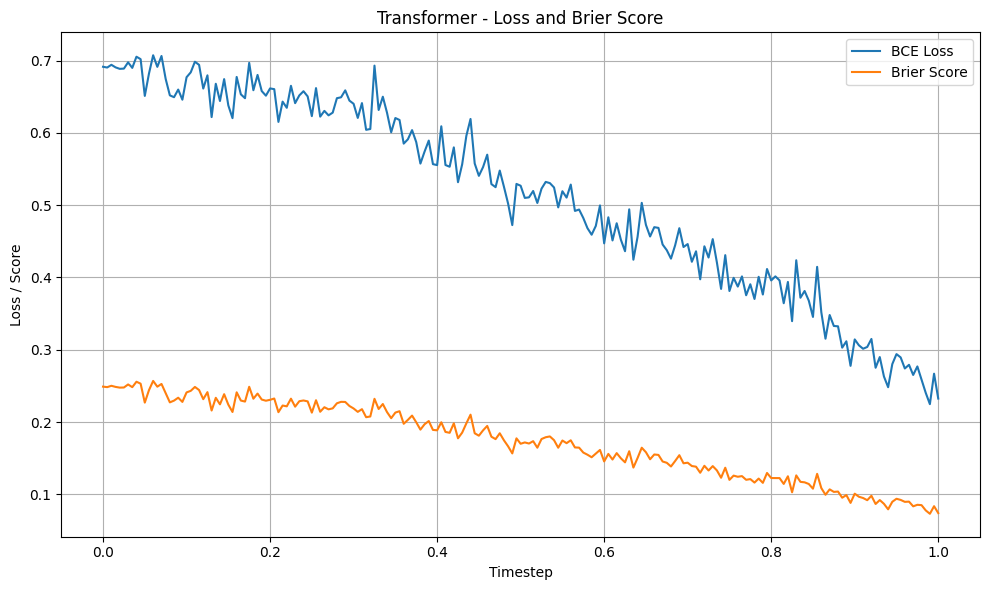

In [10]:
# # Test accuracy of model for each timestep on test data and plot
# accuracies = []
# timesteps = []
import process_data
modules_to_reload = [
    'process_data',
    'models.direct_prediction_network_transformer'
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
from models import direct_prediction_network_transformer

x = process_data.plot_loss(models, test_data, "Transformer")
# process_data.plot_accuracy(models, test_data, "Logistic Regression")

In [13]:
from process_data import write_predictions
from sklearn.preprocessing import StandardScaler
# Reload the modules
modules_to_reload = [
    'process_data',
    'models.direct_prediction_network_transformer'
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]



write_predictions(models, interpolated_dir, [2024, 2025], 4, features, replace_nan_val = 0, phat_b = "transformer_phat_b")

Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

In [14]:
import os
import shutil

# Define the ancestor directory and the parent directory
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))

# Specify a list of directories to copy
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025")
]

destination = os.path.join(dest_dir, "test_final", "transformer_model")

# Iterate through each source and copy
for source in sources:
    if os.path.exists(source):
        # Extract the year/folder name from source
        folder_name = os.path.basename(source)
        
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")

Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2024' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/transformer_model'
Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2025' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/transformer_model'
